# 01 â€” Data Collection

Pulling exchange rates and macro indicators from FRED.

**Author:** Francisco Rigon  
**Last updated:** March 2026

---

## Setup

In [1]:
import os
from datetime import datetime
from typing import Dict, Optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from fredapi import Fred
from dotenv import load_dotenv

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Reproducibility
np.random.seed(42)

print(f"Ready. Running on {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Ready. Running on 2026-03-27 14:51


In [2]:
# Load credentials
load_dotenv()

FRED_API_KEY = os.getenv('FRED_API_KEY')

if FRED_API_KEY and FRED_API_KEY != 'your_key_here':
    print("âœ“ FRED API key loaded")
else:
    print("âœ— Missing FRED API key")
    print("  1. Go to https://fred.stlouisfed.org/")
    print("  2. Create account â†’ My Account â†’ API Keys")
    print("  3. Add to .env file")

âœ“ FRED API key loaded


## Series to Collect

In [3]:
# Exchange rates (main variables)
EXCHANGE_RATES = {
    'DEXCAUS': 'USD/CAD',
    'DEXMXUS': 'USD/MXN',
    'DEXBZUS': 'USD/BRL',
}

# US macro indicators
MACRO_US = {
    'FEDFUNDS': 'Fed Funds Rate',
    'CPIAUCSL': 'CPI (inflation)',
    'GDPC1': 'Real GDP (quarterly)',
    'UNRATE': 'Unemployment',
    'INDPRO': 'Industrial Production',
}

# Trade indices
TRADE_INDICES = {
    'DTWEXBGS': 'Trade Weighted USD Index',
}

# Time range
START_DATE = '2000-01-01'
END_DATE = None  # None = today

print(f"Will collect {len(EXCHANGE_RATES) + len(MACRO_US) + len(TRADE_INDICES)} series")
print(f"Period: {START_DATE} to present")

Will collect 9 series
Period: 2000-01-01 to present


## Collection Functions

In [4]:
def get_fred_client() -> Fred:
    """Create authenticated FRED client."""
    api_key = os.getenv('FRED_API_KEY')
    if not api_key or api_key == 'your_key_here':
        raise ValueError("FRED_API_KEY not set. Check your .env file.")
    return Fred(api_key=api_key)


def fetch_series(
    fred: Fred,
    series_id: str,
    start: str = '2000-01-01',
    end: Optional[str] = None
) -> pd.Series:
    """
    Fetch a single series from FRED.
    
    Args:
        fred: Authenticated FRED client
        series_id: FRED code (e.g., 'DEXBZUS')
        start: Start date 'YYYY-MM-DD'
        end: End date (None = today)
    
    Returns:
        Series with datetime index
    """
    if end is None:
        end = datetime.now().strftime('%Y-%m-%d')
    
    data = fred.get_series(series_id, observation_start=start, observation_end=end)
    data.name = series_id
    return data


def fetch_multiple(series_dict: Dict[str, str], start: str, end: Optional[str] = None) -> pd.DataFrame:
    """
    Fetch multiple series and combine into DataFrame.
    
    Args:
        series_dict: {series_id: description}
        start: Start date
        end: End date
    
    Returns:
        DataFrame with one column per series
    """
    fred = get_fred_client()
    collected = []
    
    for series_id, desc in series_dict.items():
        print(f"  Fetching {series_id}: {desc}...", end=" ")
        try:
            s = fetch_series(fred, series_id, start, end)
            collected.append(s)
            print(f"âœ“ {len(s)} obs")
        except Exception as e:
            print(f"âœ— {e}")
    
    return pd.concat(collected, axis=1) if collected else pd.DataFrame()


print("Functions ready.")

Functions ready.


## Collect Data

In [5]:
print("="*50)
print("EXCHANGE RATES")
print("="*50)

df_fx = fetch_multiple(EXCHANGE_RATES, START_DATE, END_DATE)

print(f"\nCollected: {df_fx.shape[0]} rows, {df_fx.shape[1]} columns")
print(f"Range: {df_fx.index.min().date()} to {df_fx.index.max().date()}")

EXCHANGE RATES
  Fetching DEXCAUS: USD/CAD... 

âœ“ 6840 obs
  Fetching DEXMXUS: USD/MXN... 

âœ“ 6840 obs
  Fetching DEXBZUS: USD/BRL... 

âœ“ 6840 obs

Collected: 6840 rows, 3 columns
Range: 2000-01-03 to 2026-03-20


In [6]:
# Quick look
df_fx.tail(10)

,DEXCAUS,DEXMXUS,DEXBZUS
2026-03-09,1.3573,17.7615,5.2099
2026-03-10,1.3562,17.4765,5.1405
2026-03-11,1.3603,17.6444,5.1570
2026-03-12,1.3618,17.8350,5.2140
2026-03-13,1.3736,17.9437,5.2914
2026-03-16,1.3683,17.7654,5.2661
2026-03-17,1.3706,17.7144,5.1971
2026-03-18,1.3697,17.6840,5.2013
2026-03-19,1.3721,17.8663,5.2449
2026-03-20,1.3731,17.8874,5.2896


In [7]:
print("="*50)
print("MACRO INDICATORS")
print("="*50)

df_macro = fetch_multiple(MACRO_US, START_DATE, END_DATE)

print(f"\nCollected: {df_macro.shape[0]} rows, {df_macro.shape[1]} columns")

MACRO INDICATORS
  Fetching FEDFUNDS: Fed Funds Rate... 

âœ“ 314 obs
  Fetching CPIAUCSL: CPI (inflation)... 

âœ“ 314 obs
  Fetching GDPC1: Real GDP (quarterly)... 

âœ“ 104 obs
  Fetching UNRATE: Unemployment... 

âœ“ 314 obs
  Fetching INDPRO: Industrial Production... 

âœ“ 314 obs

Collected: 314 rows, 5 columns


In [8]:
print("="*50)
print("TRADE INDICES")
print("="*50)

df_trade = fetch_multiple(TRADE_INDICES, START_DATE, END_DATE)

print(f"\nCollected: {df_trade.shape[0]} rows")

TRADE INDICES
  Fetching DTWEXBGS: Trade Weighted USD Index... 

âœ“ 5275 obs

Collected: 5275 rows


## Industrial Production â€” Partner Countries

In [9]:
# Industrial Production for Canada, Mexico, Brazil
# Source: OECD via FRED (index 2015=100, monthly)
INDPRO_PARTNERS = {
    'CANPROINDMISMEI':    'Industrial Production - Canada',
    'MEXPRINTO02IXOBSAM': 'Industrial Production - Mexico',
    'BRAPROINDMISMEI':    'Industrial Production - Brazil',
}

print("=" * 50)
print("INDUSTRIAL PRODUCTION (Partners)")
print("=" * 50)

fred_client = get_fred_client()
indpro_series = []
country_names = ['Canada', 'Mexico', 'Brazil']

for (sid, desc), country in zip(INDPRO_PARTNERS.items(), country_names):
    print(f"  Fetching {sid}: {desc}...", end=" ")
    try:
        s = fetch_series(fred_client, sid, START_DATE, END_DATE)
        s.name = country
        indpro_series.append(s)
        print(f"âœ“ {len(s)} obs")
    except Exception as e:
        print(f"âœ— {e}")

df_indpro = pd.concat(indpro_series, axis=1)
print(f"\nCollected: {df_indpro.shape[0]} rows, {df_indpro.shape[1]} columns")
print(f"Range: {df_indpro.index.min().date()} to {df_indpro.index.max().date()}")

INDUSTRIAL PRODUCTION (Partners)
  Fetching CANPROINDMISMEI: Industrial Production - Canada... 

âœ“ 290 obs
  Fetching MEXPRINTO02IXOBSAM: Industrial Production - Mexico... 

âœ“ 286 obs
  Fetching BRAPROINDMISMEI: Industrial Production - Brazil... 

âœ“ 291 obs

Collected: 291 rows, 3 columns
Range: 2000-01-01 to 2024-03-01


## Commodities

In [10]:
# Key commodities affecting trade with Canada, Mexico, and Brazil
# WTI Oil: relevant for CAN and MEX (major oil exporters)
# Soybean: Brazil is the world largest exporter
# Iron Ore: key Brazilian export commodity
COMMODITIES = {
    "DCOILWTICO":  "WTI Crude Oil (USD/barrel)",
    "PSOYBUSDM":   "Soybean Price (USD/metric ton)",
    "PIORECRUSDM": "Iron Ore Price (USD/metric ton)",
}

print("=" * 50)
print("COMMODITIES")
print("=" * 50)

df_comm = fetch_multiple(COMMODITIES, START_DATE, END_DATE)

print(f"Collected: {df_comm.shape[0]} rows, {df_comm.shape[1]} columns")
print(f"Range: {df_comm.index.min().date()} to {df_comm.index.max().date()}")

COMMODITIES
  Fetching DCOILWTICO: WTI Crude Oil (USD/barrel)... 

âœ“ 6841 obs
  Fetching PSOYBUSDM: Soybean Price (USD/metric ton)... 

âœ“ 314 obs
  Fetching PIORECRUSDM: Iron Ore Price (USD/metric ton)... 

âœ“ 314 obs
Collected: 6932 rows, 3 columns
Range: 2000-01-01 to 2026-03-23


C:\Users\franc\AppData\Local\Temp\ipykernel_18224\1478469431.py:59: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  return pd.concat(collected, axis=1) if collected else pd.DataFrame()


## Quick Visualization

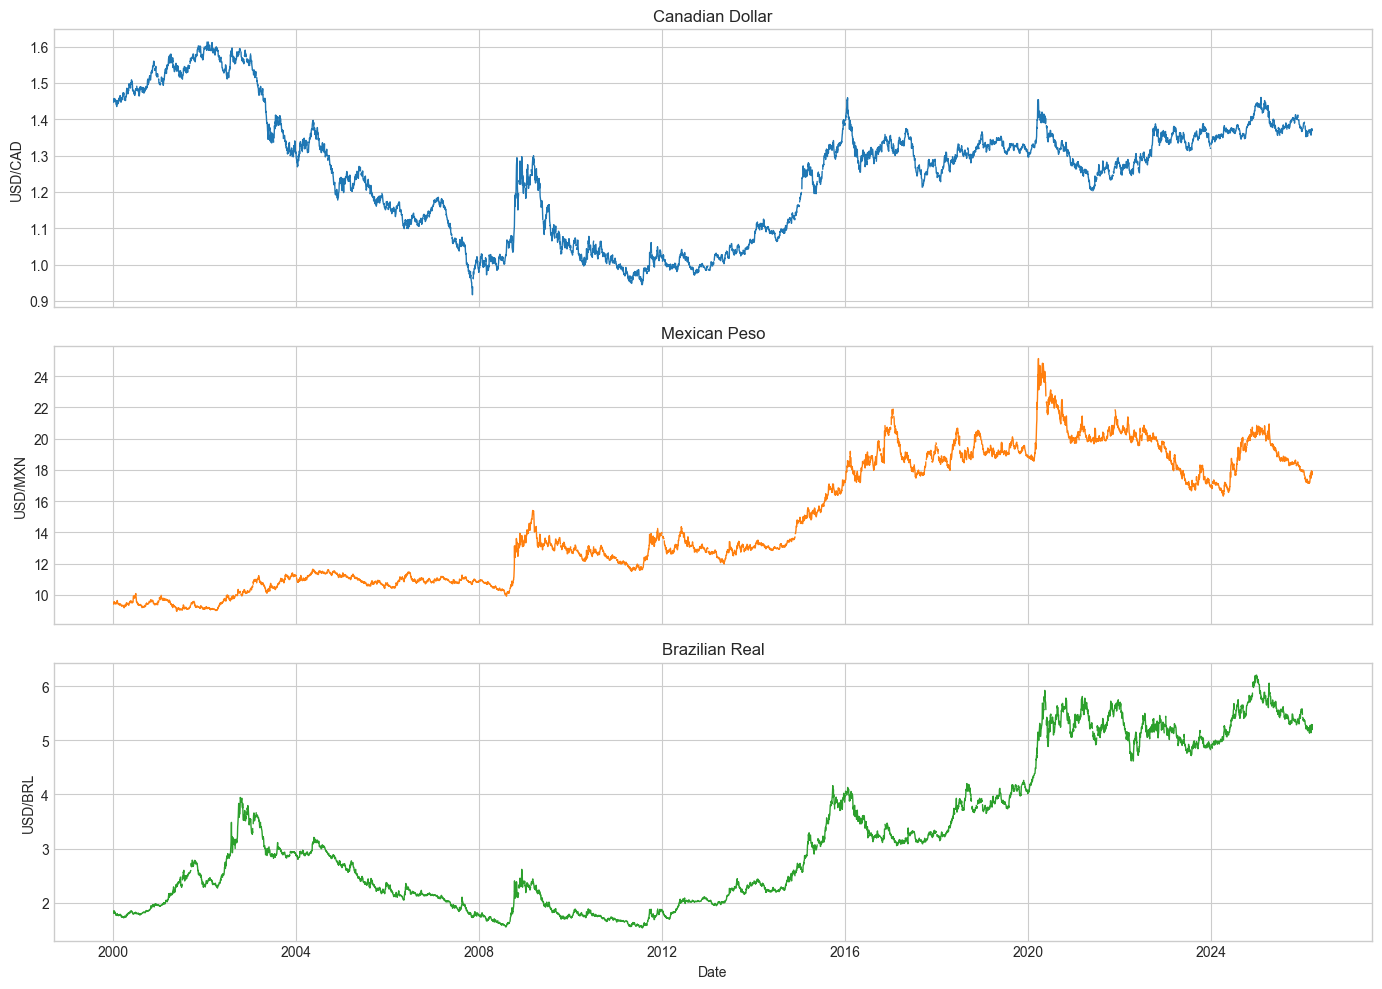

Saved to reports/figures/exchange_rates_history.png


In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# USD/CAD
axes[0].plot(df_fx['DEXCAUS'], color='#1f77b4', lw=1)
axes[0].set_ylabel('USD/CAD')
axes[0].set_title('Canadian Dollar')

# USD/MXN
axes[1].plot(df_fx['DEXMXUS'], color='#ff7f0e', lw=1)
axes[1].set_ylabel('USD/MXN')
axes[1].set_title('Mexican Peso')

# USD/BRL
axes[2].plot(df_fx['DEXBZUS'], color='#2ca02c', lw=1)
axes[2].set_ylabel('USD/BRL')
axes[2].set_title('Brazilian Real')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.savefig('../reports/figures/exchange_rates_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved to reports/figures/exchange_rates_history.png")

## Save Raw Data

In [12]:
OUT_DIR = "../data/raw"

df_fx.to_csv(f"{OUT_DIR}/fred_exchange_rates.csv")
df_macro.to_csv(f"{OUT_DIR}/fred_macro.csv")
df_trade.to_csv(f"{OUT_DIR}/fred_trade_indices.csv")
df_indpro.to_csv(f"{OUT_DIR}/fred_indpro_partners.csv")
df_comm.to_csv(f"{OUT_DIR}/fred_commodities.csv")

print("All files saved to", OUT_DIR)
print("  - fred_exchange_rates.csv")
print("  - fred_macro.csv")
print("  - fred_trade_indices.csv")
print("  - fred_indpro_partners.csv")
print("  - fred_commodities.csv")
print("Done. Next: 02_exploratory_analysis.ipynb")

All files saved to ../data/raw
  - fred_exchange_rates.csv
  - fred_macro.csv
  - fred_trade_indices.csv
  - fred_indpro_partners.csv
  - fred_commodities.csv
Done. Next: 02_exploratory_analysis.ipynb


---

**Notes:**
- Exchange rates are daily; macro data varies (monthly/quarterly)
- Frequency alignment happens in the data prep notebook
- UN Comtrade data will be added separately